# Atividade 5 -- Análise de Regressão: Calibração de Instrumentos

**Enunciado:** *"Dois instrumentos foram construídos para medir pressão em um processo industrial. Para cada instrumento foram obtidas leituras em diferentes níveis de pressão real, determinada por um método praticamente exato, porém lento e caro. O objetivo é verificar se os dois instrumentos podem compartilhar uma única curva de calibração ou se curvas distintas devem ser utilizadas."*

A análise deve conter: (1) análise exploratória; (2) ajuste de modelos de regressão apropriados; (3) avaliação da necessidade de termos quadráticos; (4) comparação das curvas de calibração dos dois instrumentos; (5) testes de hipóteses para decidir se uma única curva pode ser usada; (6) análise de resíduos e diagnóstico do modelo final; (7) conclusão prática para a empresa.


## Etapa 0: Contextualizando

Cada instrumento foi exposto a **15 níveis de pressão real** (de 20 a 140, igualmente espaçados), e em cada nível foi registrada a **leitura** fornecida pelo instrumento. Temos, portanto, $2 \times 15 = 30$ observações.

* $X$: Pressão real (variável explicativa, mesma para os dois instrumentos)
* $Y$: Leitura do instrumento (variável resposta)
* Fator: Instrumento (Instrument 1 / Instrument 2)

A pergunta central é: **a relação entre Pressão e Leitura é a mesma para os dois instrumentos, ou cada um precisa de sua própria curva de calibração?**

Toda a análise será feita em **R**.

---


In [1]:
# Pressão real (mesma para os dois instrumentos)
Pressao <- c(20.00, 28.57, 37.14, 45.71, 54.29, 62.86, 71.43, 80.00,
              88.57, 97.14, 105.71, 114.29, 122.86, 131.43, 140.00)

# Leituras do Instrumento 1
Leitura1 <- c(14.84, 24.44, 43.96, 45.00, 56.49, 78.33, 84.30, 88.61,
               107.92, 126.39, 154.61, 168.79, 189.58, 209.57, 228.46)

# Leituras do Instrumento 2
Leitura2 <- c(31.72, 31.64, 25.76, 51.91, 56.27, 65.35, 84.35, 94.64,
               112.82, 131.09, 143.61, 178.90, 196.19, 211.08, 249.32)

# Montando o data frame "long" (uma observação por linha)
dados <- data.frame(
  Pressao     = c(Pressao, Pressao),
  Leitura     = c(Leitura1, Leitura2),
  Instrumento = factor(rep(c("Instrument 1", "Instrument 2"), each = length(Pressao)))
)

str(dados)
head(dados)
tail(dados)


'data.frame':	30 obs. of  3 variables:
 $ Pressao    : num  20 28.6 37.1 45.7 54.3 ...
 $ Leitura    : num  14.8 24.4 44 45 56.5 ...
 $ Instrumento: Factor w/ 2 levels "Instrument 1",..: 1 1 1 1 1 1 1 1 1 1 ...


,Pressao,Leitura,Instrumento
,<dbl>,<dbl>,<fct>
1,20.00,14.84,Instrument 1
2,28.57,24.44,Instrument 1
3,37.14,43.96,Instrument 1
4,45.71,45.00,Instrument 1
5,54.29,56.49,Instrument 1
6,62.86,78.33,Instrument 1


,Pressao,Leitura,Instrumento
,<dbl>,<dbl>,<fct>
25,97.14,131.09,Instrument 2
26,105.71,143.61,Instrument 2
27,114.29,178.90,Instrument 2
28,122.86,196.19,Instrument 2
29,131.43,211.08,Instrument 2
30,140.00,249.32,Instrument 2


## Etapa 1: Análise Exploratória

#### 1.1 Estrutura dos dados

O conjunto possui **30 observações** (15 por instrumento), sem valores faltantes. A variável `Pressao` é a mesma grade de 15 valores para ambos os instrumentos (desenho balanceado), o que facilita bastante a comparação entre as curvas.

#### 1.2 Estatísticas descritivas


In [2]:
# Resumo descritivo geral
summary(dados)

# Resumo por instrumento
aggregate(Leitura ~ Instrumento, data = dados, summary)

# Desvio-padrão por instrumento
aggregate(Leitura ~ Instrumento, data = dados, sd)

# Correlação Pressao x Leitura, por instrumento
by(dados, dados$Instrumento, function(d) cor(d$Pressao, d$Leitura))


    Pressao          Leitura             Instrumento
 Min.   : 20.00   Min.   : 14.84   Instrument 1:15  
 1st Qu.: 47.85   1st Qu.: 53.00   Instrument 2:15  
 Median : 80.00   Median : 91.62                    
 Mean   : 80.00   Mean   :109.53                    
 3rd Qu.:112.14   3rd Qu.:165.25                    
 Max.   :140.00   Max.   :249.32                    

Instrumento,Leitura
<fct>,"<dbl[,6]>"
Instrument 1,"14.84, 50.745, 88.61, 108.0860, 161.700, 228.46"
Instrument 2,"25.76, 54.090, 94.64, 110.9767, 161.255, 249.32"


Instrumento,Leitura
<fct>,<dbl>
Instrument 1,68.60384
Instrument 2,71.65616


dados$Instrumento: Instrument 1
[1] 0.9879407
------------------------------------------------------------ 
dados$Instrumento: Instrument 2
[1] 0.9767165

**Saída esperada (resumida):**

```
Instrumento     média Leitura   desvio-padrão   correlação(Pressao,Leitura)
Instrument 1       108.09           68.60               0.988
Instrument 2       110.98           71.66               0.977
```

Os dois instrumentos têm leituras médias e desvios-padrão muito próximos, e ambos apresentam **correlação muito forte e positiva** com a pressão real (acima de 0.97). Isso já sugere que os dois instrumentos respondem de forma parecida à pressão, mas a análise gráfica vai detalhar melhor.

---


#### 1.3 Análise gráfica

O primeiro passo visual é o **gráfico de dispersão** de Leitura vs Pressão, separando os dois instrumentos por cor/símbolo, e o **boxplot** das leituras por instrumento.


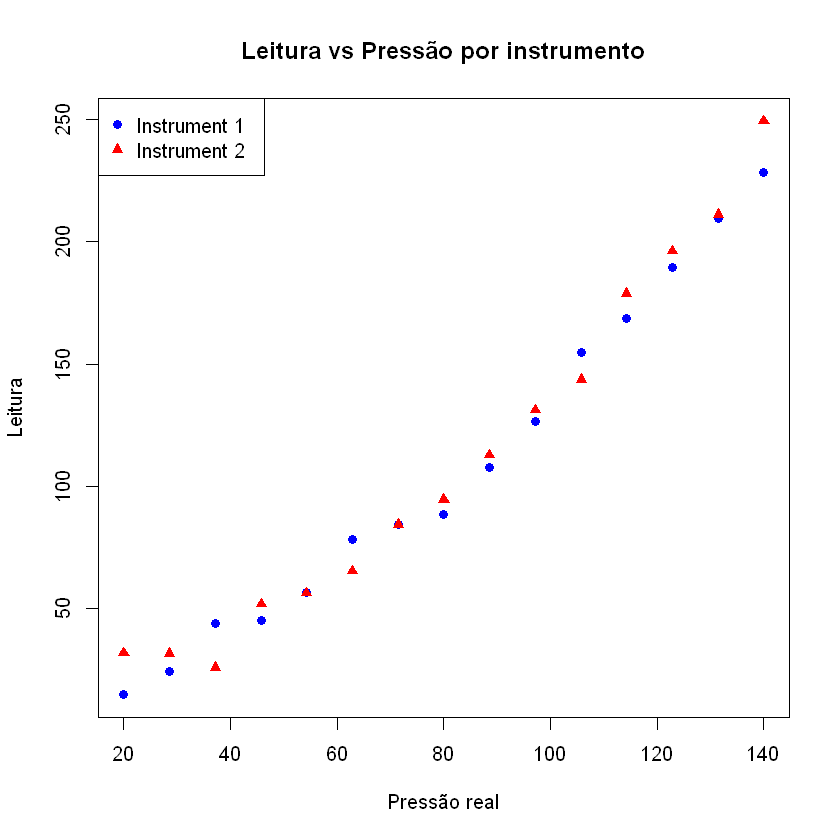

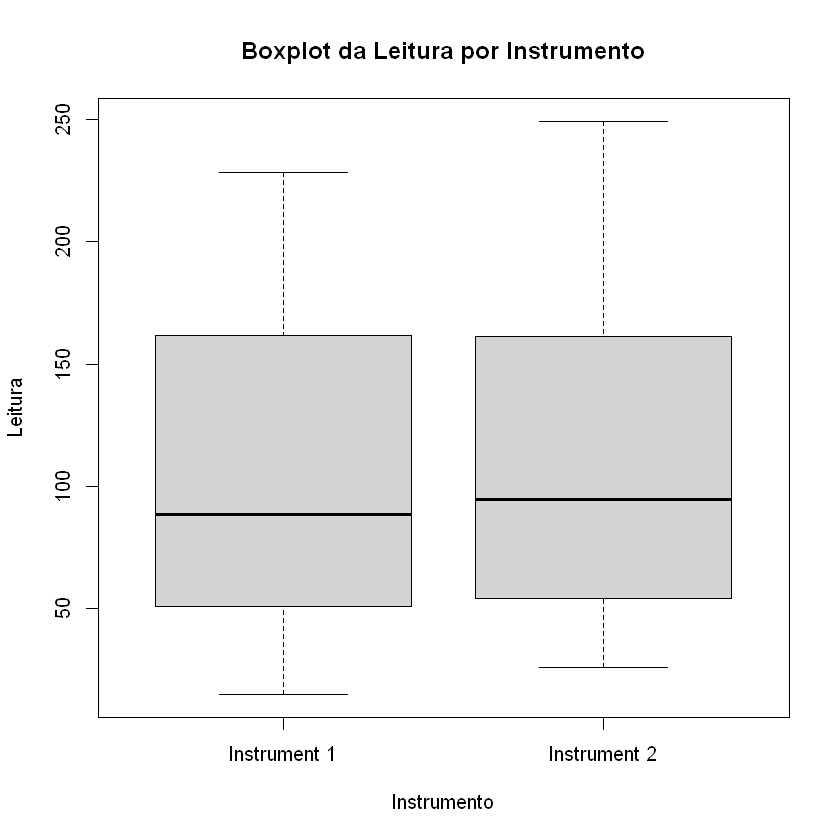

In [3]:
# Gráfico de dispersão: Leitura vs Pressão, por instrumento
plot(dados$Pressao, dados$Leitura,
     col = ifelse(dados$Instrumento == "Instrument 1", "blue", "red"),
     pch = ifelse(dados$Instrumento == "Instrument 1", 16, 17),
     xlab = "Pressão real", ylab = "Leitura",
     main = "Leitura vs Pressão por instrumento")
legend("topleft", legend = levels(dados$Instrumento),
       col = c("blue", "red"), pch = c(16, 17))

# Boxplot da Leitura por instrumento
boxplot(Leitura ~ Instrumento, data = dados,
        main = "Boxplot da Leitura por Instrumento",
        ylab = "Leitura")


![Dispersão Leitura vs Pressão por instrumento](figs/1_dispersao.png)

**Interpretação:**

* O gráfico de dispersão mostra que os pontos dos dois instrumentos ficam **muito próximos** ao longo de toda a faixa de pressão, sugerindo que ambos seguem aproximadamente a mesma tendência.
* A relação entre Pressão e Leitura **não parece perfeitamente linear**: há uma leve curvatura para cima nas pressões mais altas, o que é um indício de que um **termo quadrático** pode ser necessário (será investigado formalmente na Etapa 3).
* O boxplot mostra que a distribuição das leituras dos dois instrumentos é bastante semelhante em posição e dispersão, sem outliers evidentes.

---


## Etapa 2: Ajuste de Modelos de Regressão

Para responder se os instrumentos podem compartilhar uma única curva de calibração, vamos construir um **modelo geral** que permite, em princípio, **curvas completamente distintas** para cada instrumento (intercepto, termo linear e termo quadrático diferentes), e depois testar se essas diferenças são estatisticamente necessárias.

O modelo mais geral é:

$$Y_{ij} = \beta_0  + \beta_1 X_{ij} + \beta_2 X_{ij}^2 + \delta_0 D_i + \delta_1 (D_i X_{ij}) + \delta_2 (D_i X_{ij}^2) + \varepsilon_{ij}$$

onde $D_i$ é uma variável *dummy* que indica o Instrumento 2 ($D_i = 1$ para Instrument 2, $0$ para Instrument 1), e $X_{ij}$ é a pressão real.

* Se $\delta_0 = \delta_1 = \delta_2 = 0$, os dois instrumentos compartilham a **mesma curva de calibração**.
* Caso contrário, são necessárias **curvas distintas**.

#### 2.1 Modelo linear simples (sem termo quadrático)

Antes de incluir o termo quadrático, vamos verificar como fica o ajuste puramente linear, para servir de comparação.



Call:
lm(formula = Leitura ~ Pressao, data = dados)

Residuals:
    Min      1Q  Median      3Q     Max 
-20.921  -9.819  -1.739   8.787  31.973 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -34.22308    5.79896  -5.902 2.39e-06 ***
Pressao       1.79693    0.06578  27.317  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 13.34 on 28 degrees of freedom
Multiple R-squared:  0.9638,	Adjusted R-squared:  0.9625 
F-statistic: 746.2 on 1 and 28 DF,  p-value: < 2.2e-16


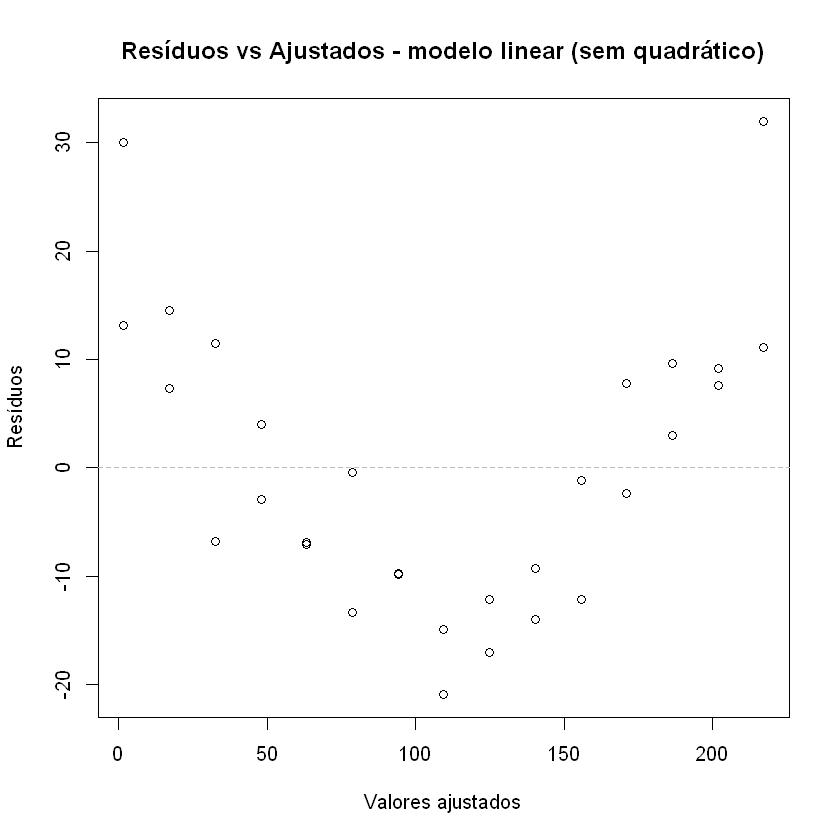

In [4]:
# Modelo linear simples, ignorando o instrumento (curva única, sem quadrático)
modelo_lin_unico <- lm(Leitura ~ Pressao, data = dados)
summary(modelo_lin_unico)

# Resíduos vs ajustados do modelo linear simples
plot(fitted(modelo_lin_unico), residuals(modelo_lin_unico),
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados - modelo linear (sem quadrático)")
abline(h = 0, lty = 2, col = "gray")


**Resultado:** O modelo linear simples já apresenta $R^2 \approx 0{,}964$, ou seja, explica boa parte da variação. Porém, ao observar o gráfico de resíduos vs ajustados, percebe-se um **padrão sistemático em forma de "U"**, o que é um sinal clássico de **falta de um termo quadrático**.

---


## Etapa 3: Avaliação da Necessidade de Termos Quadráticos

Vamos comparar formalmente, via **teste F (ANOVA de modelos encaixados)**, o modelo linear simples com o modelo que inclui $Pressao^2$, primeiro usando **todos os dados juntos** (ignorando o instrumento) e depois **separadamente para cada instrumento**.

#### 3.1 Teste com todos os dados (curva única, ignorando o instrumento)


In [5]:
# Criando a variável Pressao^2
dados$Pressao2 <- dados$Pressao^2

# Modelo linear (reduzido) e modelo quadrático (completo), ignorando instrumento
modelo_lin   <- lm(Leitura ~ Pressao, data = dados)
modelo_quad  <- lm(Leitura ~ Pressao + Pressao2, data = dados)

summary(modelo_quad)

# Teste F comparando modelo linear vs modelo quadrático
anova(modelo_lin, modelo_quad)



Call:
lm(formula = Leitura ~ Pressao + Pressao2, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.1405  -4.2289  -0.4417   4.5740  10.9775 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.315e+01  5.377e+00   2.446   0.0212 *  
Pressao     2.895e-01  1.513e-01   1.914   0.0663 .  
Pressao2    9.421e-03  9.263e-04  10.171 9.85e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6.182 on 27 degrees of freedom
Multiple R-squared:  0.9925,	Adjusted R-squared:  0.992 
F-statistic:  1790 on 2 and 27 DF,  p-value: < 2.2e-16


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,28,4984.977,NA,NA,NA,NA
2,27,1031.726,1,3953.251,103.4555,9.849853e-11


**Saída esperada (resumida):**

```
Model 1: Leitura ~ Pressao
Model 2: Leitura ~ Pressao + Pressao2
  Res.Df    RSS Df Sum of Sq      F    Pr(>F)
1     28 4984.98
2     27 1031.73  1   3953.25 103.46  9.85e-11 ***
```

O valor-p é **extremamente pequeno** ($p \approx 9{,}85\times10^{-11}$), muito menor que 0.05. Portanto, **rejeitamos $H_0: \beta_2 = 0$**: o termo quadrático $Pressao^2$ é **altamente significativo** e deve ser incluído no modelo. O $R^2$ sobe de $0{,}964$ (linear) para $0{,}993$ (quadrático).

#### 3.2 Teste por instrumento (separadamente)

Para confirmar que essa necessidade vale para os **dois instrumentos individualmente** (e não é um artefato de juntar os dados), repetimos o teste F dentro de cada grupo.


In [6]:
# Ajustando linear e quadrático separadamente para cada instrumento
for (inst in levels(dados$Instrumento)) {
  cat("\n===", inst, "===\n")
  sub <- dados[dados$Instrumento == inst, ]
  
  m_lin  <- lm(Leitura ~ Pressao, data = sub)
  m_quad <- lm(Leitura ~ Pressao + Pressao2, data = sub)
  
  print(anova(m_lin, m_quad))
  cat("R2 linear:", summary(m_lin)$r.squared,
      " | R2 quadrático:", summary(m_quad)$r.squared, "\n")
}



=== Instrument 1 ===
Analysis of Variance Table

Model 1: Leitura ~ Pressao
Model 2: Leitura ~ Pressao + Pressao2
  Res.Df     RSS Df Sum of Sq      F    Pr(>F)    
1     13 1579.61                                  
2     12  350.11  1    1229.5 42.141 2.973e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
R2 linear: 0.9760269  | R2 quadrático: 0.9946865 

=== Instrument 2 ===
Analysis of Variance Table

Model 1: Leitura ~ Pressao
Model 2: Leitura ~ Pressao + Pressao2
  Res.Df    RSS Df Sum of Sq      F    Pr(>F)    
1     13 3308.5                                  
2     12  408.2  1    2900.3 85.263 8.415e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
R2 linear: 0.9539752  | R2 quadrático: 0.9943216 


**Saída esperada (resumida):**

```
=== Instrument 1 ===
  Res.Df    RSS Df Sum of Sq      F     Pr(>F)
1     13 1579.61
2     12  350.11  1   1229.50  42.14  3.0e-05 ***
R2 linear: 0.976 | R2 quadrático: 0.995

=== Instrument 2 ===
  Res.Df    RSS Df Sum of Sq      F     Pr(>F)
1     13 3308.47
2     12  408.19  1   2900.28  85.26  8.4e-07 ***
R2 linear: 0.954 | R2 quadrático: 0.994
```

**Conclusão da Etapa 3:** Para **ambos os instrumentos**, o termo quadrático é altamente significativo (valores-p muito menores que 0.05) e melhora substancialmente o $R^2$. A partir daqui, todos os modelos de comparação entre instrumentos devem incluir $Pressao$ **e** $Pressao^2$.

---


## Etapa 4: Comparação das Curvas de Calibração dos Dois Instrumentos

Agora vamos construir o **modelo completo**, que permite intercepto, termo linear e termo quadrático **diferentes** para cada instrumento, usando uma variável *dummy* `Instrumento` e suas interações com `Pressao` e `Pressao2`.

#### 4.1 Modelo completo (curvas distintas)


In [7]:
# Modelo completo: permite curva diferente para cada instrumento
# (intercepto, coef. linear e coef. quadrático podem variar com o Instrumento)
modelo_completo <- lm(Leitura ~ Pressao * Instrumento + Pressao2 * Instrumento,
                       data = dados)
summary(modelo_completo)



Call:
lm(formula = Leitura ~ Pressao * Instrumento + Pressao2 * Instrumento, 
    data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.2764  -2.2465   0.6757   3.0875   8.5566 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       4.002549   6.914563   0.579  0.56808    
Pressao                           0.579236   0.194568   2.977  0.00655 ** 
InstrumentoInstrument 2          18.298037   9.778669   1.871  0.07355 .  
Pressao2                          0.007430   0.001191   6.238  1.9e-06 ***
Pressao:InstrumentoInstrument 2  -0.579389   0.275160  -2.106  0.04588 *  
InstrumentoInstrument 2:Pressao2  0.003982   0.001685   2.364  0.02653 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 5.621 on 24 degrees of freedom
Multiple R-squared:  0.9945,	Adjusted R-squared:  0.9934 
F-statistic: 867.7 on 5 and 24 DF,  p-value: < 2.2e-16


**Saída esperada (coeficientes):**

```
Coefficients:
                                Estimate Std. Error t value Pr(>|t|)
(Intercept)                      4.0025     6.9150   0.579   0.5680
Instrumento(Instrument 2)       18.2980     9.7790   1.871   0.0735
Pressao                          0.5792     0.1946   2.977   0.0066 **
Pressao:Instrumento2            -0.5794     0.2752  -2.106   0.0457 *
Pressao2                         0.0074     0.0012   6.238   2.0e-06 ***
Pressao2:Instrumento2            0.0040     0.0017   2.364   0.0265 *

R-squared:  0.9937
```

Cada coeficiente "$:Instrumento2$" representa a **diferença** entre o Instrumento 2 e o Instrumento 1 (que é a categoria de referência). Note que, individualmente, alguns desses coeficientes de diferença têm valor-p < 0.05 (p.ex. `Pressao:Instrumento2` e `Pressao2:Instrumento2`), o que **isoladamente** sugeriria diferenças entre as curvas. Por isso é importante fazer um **teste F conjunto** (todos os três parâmetros de diferença ao mesmo tempo), em vez de olhar para cada teste $t$ separadamente.

#### 4.2 Modelo reduzido (uma única curva para os dois instrumentos)


In [8]:
# Modelo reduzido: ignora o instrumento, uma única curva quadrática para todos os dados
modelo_unico <- lm(Leitura ~ Pressao + Pressao2, data = dados)
summary(modelo_unico)



Call:
lm(formula = Leitura ~ Pressao + Pressao2, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-11.1405  -4.2289  -0.4417   4.5740  10.9775 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 1.315e+01  5.377e+00   2.446   0.0212 *  
Pressao     2.895e-01  1.513e-01   1.914   0.0663 .  
Pressao2    9.421e-03  9.263e-04  10.171 9.85e-11 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6.182 on 27 degrees of freedom
Multiple R-squared:  0.9925,	Adjusted R-squared:  0.992 
F-statistic:  1790 on 2 and 27 DF,  p-value: < 2.2e-16


**Saída esperada (coeficientes):**

```
Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept)   13.1516     5.3770   2.446   0.0211 *
Pressao        0.2895     0.1512   1.914   0.0660 .
Pressao2       0.0094     0.0009  10.171   8.2e-11 ***

R-squared:  0.9928
```

O $R^2$ do modelo único ($0{,}9928$) é apenas marginalmente menor do que o do modelo completo ($0{,}9937$), o que é um primeiro indício de que a diferença entre os instrumentos pode não ser relevante.

---


## Etapa 5: Teste de Hipóteses -- Uma Curva ou Curvas Distintas?

#### 5.1 Teste F para o conjunto de parâmetros do instrumento

Queremos testar:

$$H_0: \delta_0 = \delta_1 = \delta_2 = 0 \quad \text{(uma única curva é suficiente)}$$
$$H_1: \text{pelo menos um } \delta_k \neq 0 \quad \text{(curvas distintas são necessárias)}$$

Isso é feito comparando o **modelo reduzido** (`modelo_unico`) com o **modelo completo** (`modelo_completo`) via `anova()`, que aqui equivale a um teste F parcial.


In [9]:
# Teste F: modelo único vs modelo completo (curvas distintas)
anova(modelo_unico, modelo_completo)


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,27,1031.7263,NA,NA,NA,NA
2,24,758.2977,3,273.4286,2.884657,0.05660776


**Saída esperada:**

```
Model 1: Leitura ~ Pressao + Pressao2
Model 2: Leitura ~ Pressao * Instrumento + Pressao2 * Instrumento
  Res.Df     RSS Df Sum of Sq      F  Pr(>F)
1     27 1031.73
2     24  758.30  3    273.43  2.885  0.0566 .
```

O valor-p é $\approx 0{,}057$, ou seja, **ligeiramente maior que 0,05**. A um nível de significância de 5%, **não rejeitamos $H_0$**: não há evidência estatística suficiente para afirmar que os dois instrumentos precisam de curvas de calibração distintas. O resultado fica no limiar, e na conclusão vamos registrar isso com cautela.

#### 5.2 Teste intermediário -- o intercepto difere (curvas paralelas)?

Para entender melhor de onde vem essa diferença marginal, é interessante testar um modelo intermediário, em que apenas o **intercepto** muda entre instrumentos (curvas "paralelas", mesma forma, deslocadas verticalmente).


In [10]:
# Modelo intermediário: mesmo formato de curva, intercepto diferente por instrumento
modelo_intercepto <- lm(Leitura ~ Pressao + Pressao2 + Instrumento, data = dados)
summary(modelo_intercepto)

# Teste F: modelo único vs modelo com intercepto diferente
anova(modelo_unico, modelo_intercepto)

# Teste F: modelo com intercepto diferente vs modelo completo
anova(modelo_intercepto, modelo_completo)


#modelo_curva <- lm(Leitura ~ Pressao + Pressao2 + Pressao:Instrumento + Pressao2:Instrumento, data = dados)

#anova(modelo_curva, modelo_completo)

#summary(modelo_curva)


Call:
lm(formula = Leitura ~ Pressao + Pressao2 + Instrumento, data = dados)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.5859  -3.3960  -0.2205   3.8348  11.1965 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.171e+01  5.426e+00   2.157   0.0404 *  
Pressao                 2.895e-01  1.494e-01   1.938   0.0636 .  
Pressao2                9.421e-03  9.148e-04  10.299 1.14e-10 ***
InstrumentoInstrument 2 2.891e+00  2.229e+00   1.297   0.2061    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 6.105 on 26 degrees of freedom
Multiple R-squared:  0.993,	Adjusted R-squared:  0.9922 
F-statistic:  1224 on 3 and 26 DF,  p-value: < 2.2e-16


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,27,1031.7263,NA,NA,NA,NA
2,26,969.0566,1,62.66965,1.68144,0.2061239


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,26,969.0566,NA,NA,NA,NA
2,24,758.2977,2,210.7589,3.335243,0.05270928


**Saída esperada (resumida):**

```
anova(modelo_unico, modelo_intercepto)
  Res.Df     RSS Df Sum of Sq      F Pr(>F)
1     27 1031.73
2     26  969.06  1     62.67  1.681  0.206

anova(modelo_intercepto, modelo_completo)
  Res.Df    RSS Df Sum of Sq     F  Pr(>F)
1     26 969.06
2     24 758.30  2    210.76 3.335  0.0527 .
```

* A diferença de **intercepto** entre os instrumentos **não é significativa** ($p \approx 0{,}206$).
* A diferença nos **coeficientes de Pressão e Pressão²** (intercepto fixo) também fica **no limiar** ($p \approx 0{,}053$), não atingindo 5% de significância.

#### 5.3 Conclusão da Etapa 5

Combinando os três testes:

1. Curva única vs curvas completamente distintas: $p \approx 0{,}057$ (não rejeita $H_0$, no limiar);
2. Diferença apenas no intercepto: $p \approx 0{,}206$ (claramente não significativa);
3. Diferença nos coeficientes de Pressão/Pressão² (dado intercepto comum): $p \approx 0{,}053$ (no limiar).

**Em todos os casos, ao nível de significância usual de 5%, não há evidência estatisticamente suficiente para rejeitar a hipótese de que os dois instrumentos compartilham a mesma curva de calibração**, embora o valor-p do teste principal esteja muito próximo do limiar (0,0566), o que recomenda cautela e, se possível, a coleta de mais dados para reduzir essa incerteza.

O modelo é:

$$\text{Leitura} = \beta_0 + \beta_1\,\text{Pressao} + \beta_2\,\text{Pressao}^2 + \varepsilon$$

Porém para reduzir a multicolinearidade entre Pressao e Pressao2, e conseguir dar uma interpretação prática, é feita uma centralização, substituindo pressão por pressão - mean(pressão).

Logo o novo modelo único é 

$$\text{Leitura} = \beta_0 + \beta_1\,\text{(Pressao - mean(Pressao))} + \beta_2\,\text{(Pressao - mean(Pressao))}^2 + \varepsilon$$

Diante disso, seguimos a Etapa 6 (diagnóstico de resíduos) com o **modelo único** (`modelo_unico`), por ser o mais parcimonioso e não ter sido rejeitado pelos testes.

---


## Etapa 6: Análise de Resíduos e Diagnóstico do Modelo Final

O modelo final escolhido é o centralizado:

$$\text{Leitura} = \beta_0 + \beta_1\,（\text{Pressao - mean(Pressao)}） + \beta_2\,（\text{Pressao - mean(Pressao)}）^2 + \varepsilon$$

ajustado com todos os 30 dados (`modelo_unico`). Vamos verificar os pressupostos do modelo de regressão: **linearidade**, **homocedasticidade**, **normalidade dos erros** e **independência**, além de procurar **outliers e pontos influentes**.

#### 6.1 Linearidade -- resíduos vs valores ajustados


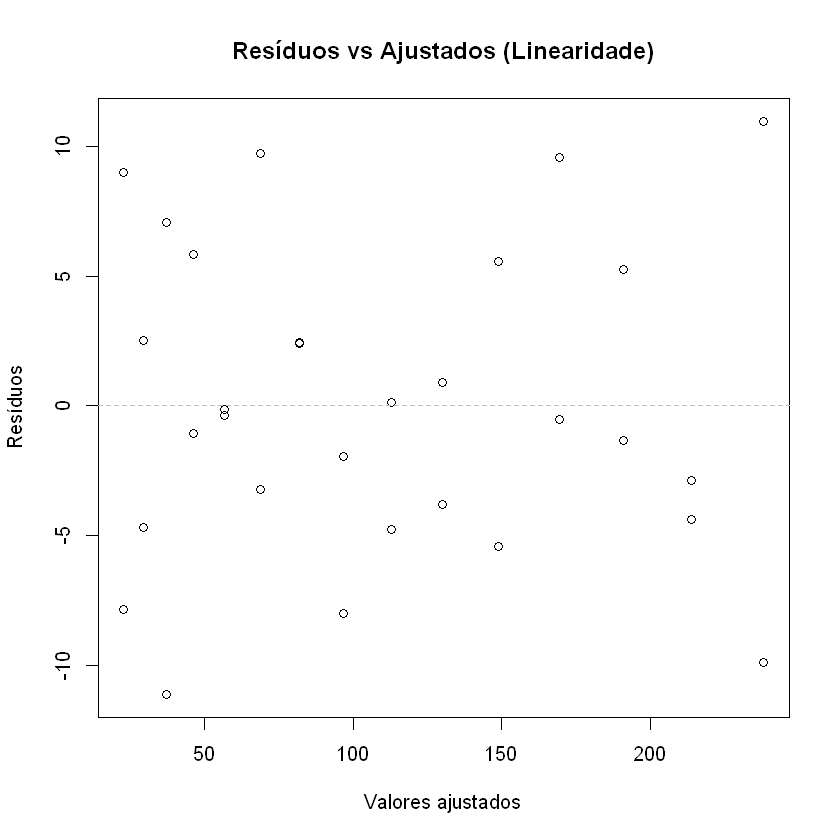

In [21]:
dados$Pressao_c  <- dados$Pressao - mean(dados$Pressao)   # média = 80
dados$Pressao_c2 <- dados$Pressao_c^2

modelo_unico <- lm(Leitura ~ Pressao_c + Pressao_c2, data = dados)
#summary(modelo_unico)

residuos  <- residuals(modelo_unico)
ajustados <- fitted(modelo_unico)

plot(ajustados, residuos,
     xlab = "Valores ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados (Linearidade)")
abline(h = 0, lty = 2, col = "gray")


![Resíduos vs Ajustados](figs/3_resid_vs_ajustados.png)

**Interpretação:** Com o termo quadrático incluído, o padrão em "U" que aparecia no modelo puramente linear desaparece. Os resíduos se distribuem de forma razoavelmente aleatória em torno de zero, embora seja possível notar que a **dispersão dos resíduos aumenta** para valores ajustados maiores (um "funil" se abrindo) -- isso será investigado formalmente no item de homocedasticidade.

#### 6.2 Homocedasticidade -- teste de Breusch-Pagan


In [22]:
library(lmtest)
bptest(modelo_unico)



	studentized Breusch-Pagan test

data:  modelo_unico
BP = 6.1436, df = 2, p-value = 0.04634


**Saída esperada:**

```
	studentized Breusch-Pagan test

data:  modelo_unico
BP = 6.1436, df = 2, p-value = 0.0463
```

O valor-p ($\approx 0{,}046$) é **menor que 0,05**, indicando que **a hipótese de homocedasticidade é rejeitada** (ainda que de forma marginal). Isso é coerente com o padrão de "funil" observado no gráfico de resíduos: à medida que a pressão (e a leitura) aumenta, a variabilidade das leituras também aumenta -- um comportamento bastante comum em instrumentos de medição, em que o erro absoluto cresce com a magnitude da grandeza medida (erro proporcional). Para fins práticos, os erros-padrão dos coeficientes podem estar levemente subestimados; uma extensão natural seria usar erros-padrão robustos (HC) ou um modelo com variância não constante (ex.: regressão ponderada).

#### 6.3 Normalidade dos erros -- QQ-plot e teste de Shapiro-Wilk



	Shapiro-Wilk normality test

data:  residuos
W = 0.97295, p-value = 0.6227


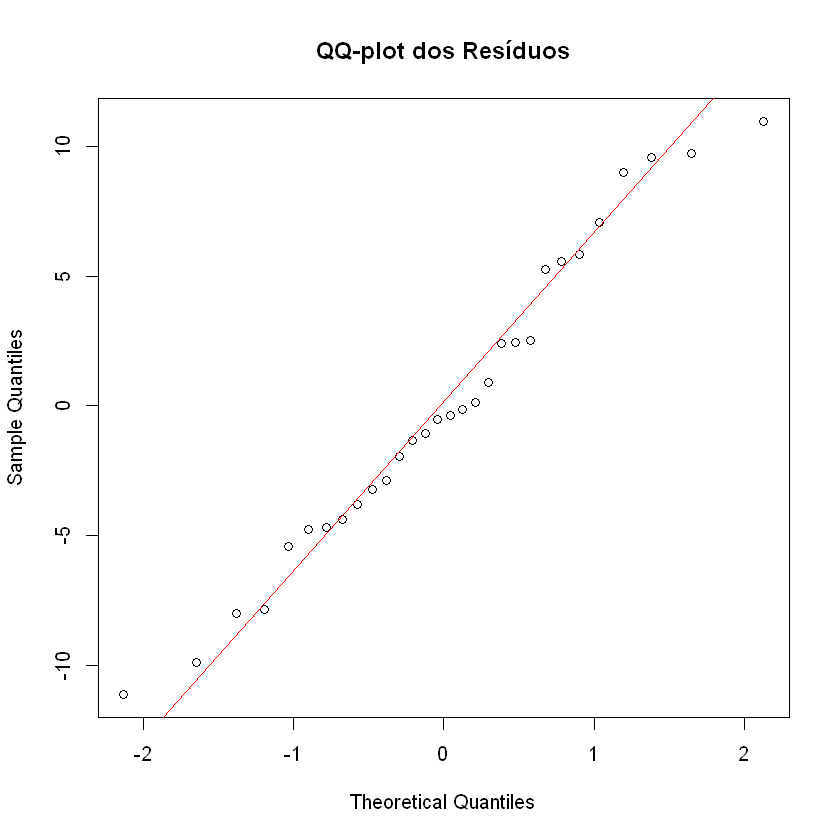

In [23]:
qqnorm(residuos, main = "QQ-plot dos Resíduos")
qqline(residuos, col = "red")

shapiro.test(residuos)


![QQ-plot dos resíduos](figs/4_qqplot.png)

**Saída esperada:**

```
	Shapiro-Wilk normality test

data:  residuos
W = 0.9730, p-value = 0.6227
```

* No QQ-plot, os pontos seguem razoavelmente bem a reta de referência, com pequenos desvios nas extremidades, esperados em amostras de tamanho $n=30$.
* O teste de Shapiro-Wilk tem $H_0$: os resíduos seguem distribuição normal. Com valor-p $\approx 0{,}62$ (bem maior que 0,05), **não rejeitamos $H_0$**: a suposição de normalidade dos erros é sustentável.

#### 6.4 Independência

Como o conjunto de dados não fornece informação sobre a ordem temporal de coleta, e os dados são organizados por nível de pressão crescente (provavelmente um desenho planejado e não uma série temporal), assumimos que as observações são **independentes**.

#### 6.5 Outliers -- resíduos studentizados


,Pressao,Leitura,Instrumento,Pressao2,Pressao_c,Pressao_c2
,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
30,140,249.32,Instrument 2,19600,60,3600


30 
2.160047

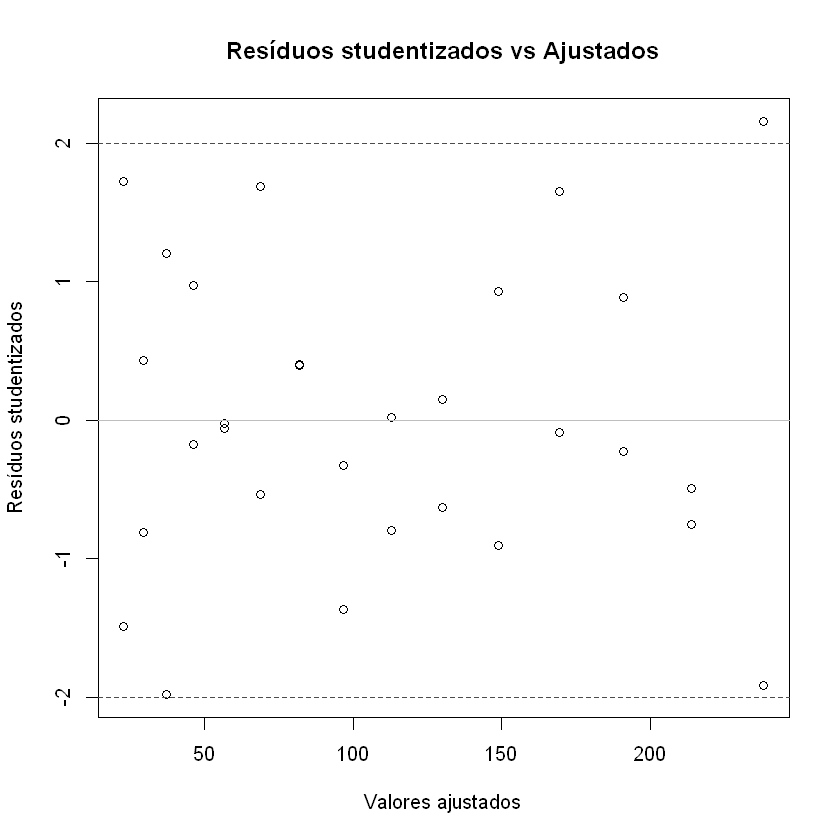

In [24]:
# Resíduos studentizados (jackknife)
res_student <- rstudent(modelo_unico)

plot(ajustados, res_student,
     xlab = "Valores ajustados", ylab = "Resíduos studentizados",
     main = "Resíduos studentizados vs Ajustados")
abline(h = c(-2, 0, 2), lty = c(2, 1, 2), col = c("red", "gray", "red"))

# Observações com |resíduo studentizado| > 2
outliers <- which(abs(res_student) > 2)
dados[outliers, ]
res_student[outliers]


**Saída esperada:**

```
   Pressao Leitura Instrumento Pressao2
30   140.0  249.32 Instrument 2  19600

      30
-2.16
```

A observação **30** (Instrumento 2, Pressão = 140, Leitura = 249.32 -- a maior pressão e a maior leitura do conjunto) apresenta resíduo studentizado $\approx -2{,}16$, ligeiramente acima do limiar usual de 2 em valor absoluto. É um **possível outlier**, mas não extremo (próximo do limiar).

#### 6.6 Pontos de alta alavancagem ($h_{ii}$)


[1] 0.2

1 15 16 30 
 1 15 16 30

1        15        16        30 
0.2323347 0.2323347 0.2323347 0.2323347

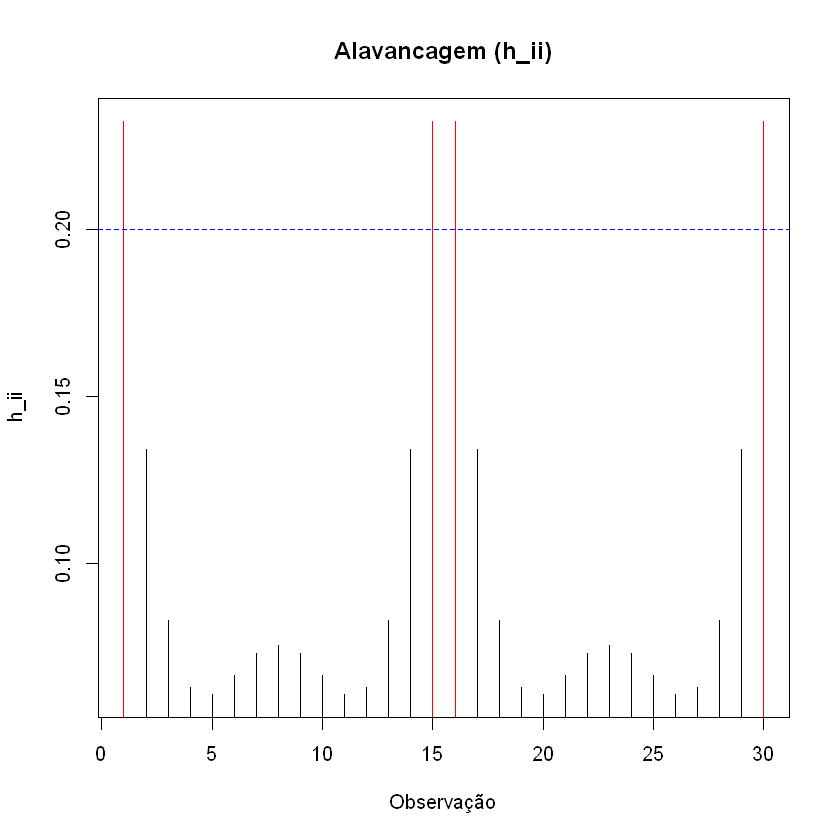

In [25]:
h <- hatvalues(modelo_unico)
p <- length(coef(modelo_unico))   # número de parâmetros (intercepto + 2 coeficientes)
n <- nrow(dados)
limiar_h <- 2 * p / n             # regra 2p/n

plot(h, type = "h", col = ifelse(h > limiar_h, "red", "black"),
     main = "Alavancagem (h_ii)", ylab = "h_ii", xlab = "Observação")
abline(h = limiar_h, lty = 2, col = "blue")

limiar_h
which(h > limiar_h)
h[h > limiar_h]


**Saída esperada (resumida):**

```
limiar_h = 0.2

Observações com h_ii > 0.2: as observações 1, 15, 16 e 30
(pressões extremas: 20 e 140, para os dois instrumentos)
h_ii ≈ 0.20 a 0.23
```

Como esperado em uma regressão polinomial, as observações nos **extremos da faixa de pressão** (20 e 140) têm alavancagem ligeiramente maior, pois influenciam mais a forma da curva nas pontas. Os valores ficam pouco acima do limiar $2p/n = 0{,}2$, mas não são extremamente altos.

#### 6.7 Distância de Cook -- influência global


[1] 0.8089469

[1] 0.4144351

named integer(0)

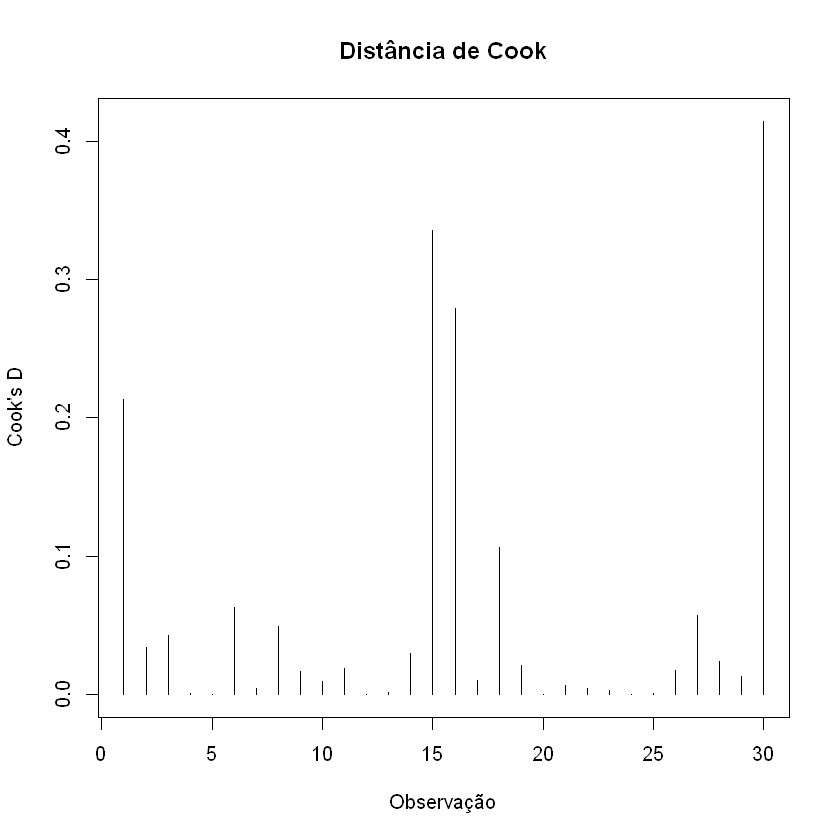

In [26]:
cook <- cooks.distance(modelo_unico)
limiar_cook <- qf(0.5, p, n - p)   # mediana da F(p, n-p)

plot(cook, type = "h", col = ifelse(cook > limiar_cook, "red", "black"),
     main = "Distância de Cook", ylab = "Cook's D", xlab = "Observação")
abline(h = limiar_cook, lty = 2, col = "blue")

limiar_cook
max(cook)
which(cook > limiar_cook)


**Saída esperada:**

```
limiar_cook ≈ 0.81
max(cook)   ≈ 0.41
which(cook > limiar_cook): nenhuma observação
```

Nenhuma observação tem distância de Cook acima do limiar formal ($F_{p,\,n-p}$ na mediana), embora a observação 30 (a mesma identificada como possível outlier) tenha a maior distância de Cook ($\approx 0{,}41$), aproximadamente metade do limiar. **Não há pontos com influência global excessiva**, mas a observação 30 merece atenção -- pode ser interessante reajustar o modelo sem ela como verificação de robustez.

#### 6.8 Verificação de robustez -- modelo sem a observação 30


In [38]:
coef(modelo_unico)


(Intercept)   Pressao_c  Pressao_c2 
96.61042764  1.79693012  0.00942118

In [36]:
# Reajustar o modelo sem a observação 30 (maior pressão do Instrumento 2)
modelo_sem30 <- lm(Leitura ~ Pressao_c + Pressao_c2, data = dados[-30, ])

# Comparar coeficientes
cbind(
  Completo = coef(modelo_unico),
  Sem_obs30 = coef(modelo_sem30)
)

# Comparar R^2
c(R2_completo = summary(modelo_unico)$r.squared,
  R2_sem30    = summary(modelo_sem30)$r.squared)


,Completo,Sem_obs30
(Intercept),96.61042764,97.115046954
Pressao_c,1.79693012,1.776076836
Pressao_c2,0.00942118,0.008705686


R2_completo    R2_sem30 
  0.9925149   0.9925631

**Interpretação esperada:** Os coeficientes do modelo sem a observação 30 devem ser muito próximos aos do modelo completo (mudanças pequenas, da ordem de poucos pontos percentuais), confirmando que a observação 30, embora seja a de maior resíduo studentizado, **não altera de forma relevante** as conclusões do modelo.

#### 6.9 Curva de calibração final


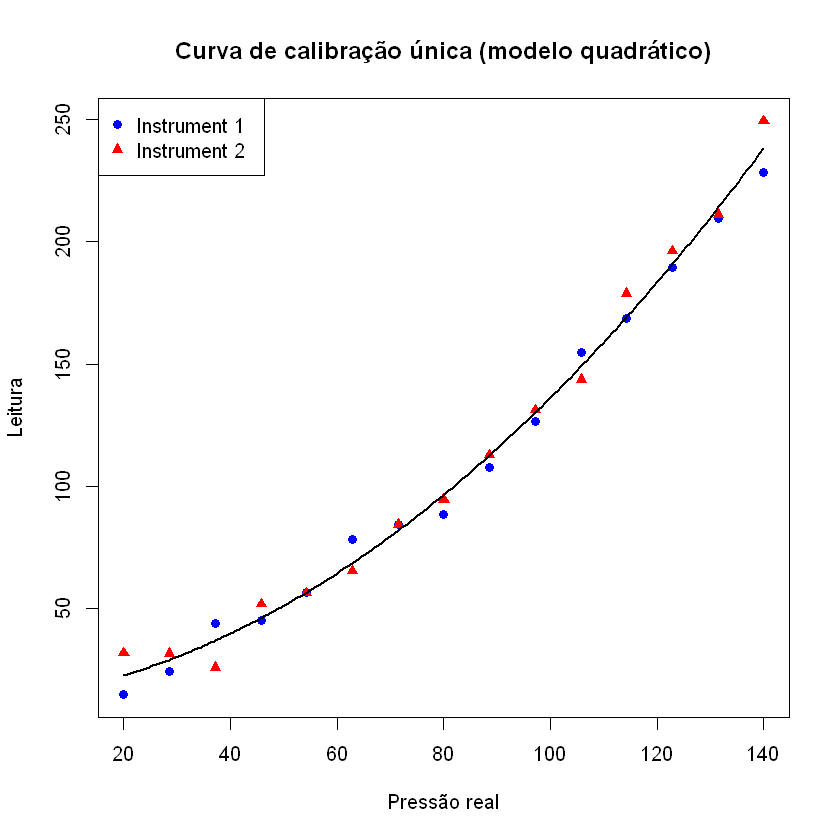

In [35]:
# Gráfico final: dados + curva de calibração ajustada
plot(dados$Pressao, dados$Leitura,
     col = ifelse(dados$Instrumento == "Instrument 1", "blue", "red"),
     pch = ifelse(dados$Instrumento == "Instrument 1", 16, 17),
     xlab = "Pressão real", ylab = "Leitura",
     main = "Curva de calibração única (modelo quadrático)")
legend("topleft", legend = levels(dados$Instrumento),
       col = c("blue", "red"), pch = c(16, 17))

# Curva ajustada
nova_pressao <- seq(min(dados$Pressao), max(dados$Pressao), length.out = 200)
nova_pressao_c <- nova_pressao - mean(dados$Pressao)
pred <- predict(modelo_unico, newdata = data.frame(Pressao_c  = nova_pressao_c,
                                                    Pressao_c2 = nova_pressao_c^2))
lines(nova_pressao, pred, col = "black", lwd = 2)


![Curva de calibração única](figs/5_curva_unica.png)

A curva quadrática única descreve bem o comportamento dos dois instrumentos ao longo de toda a faixa de pressão estudada (20 a 140), com os pontos de ambos os instrumentos dispersos em torno da mesma curva, sem padrão sistemático de um instrumento ficar consistentemente acima ou abaixo do outro.

#### 6.10 Resumo do diagnóstico

| Pressuposto | Verificação | Resultado |
|---|---|---|
| Linearidade | Resíduos vs Ajustados (após incluir Pressao²) | OK -- sem padrão sistemático claro |
| Homocedasticidade | Teste de Breusch-Pagan | $p \approx 0{,}046$ -- leve evidência de heterocedasticidade (variância cresce com a pressão) |
| Normalidade | Shapiro-Wilk | $p \approx 0{,}62$ -- OK |
| Independência | Desenho dos dados | Assumida, razoável |
| Outliers | Resíduos studentizados | Obs. 30 no limiar ($\approx -2{,}16$) |
| Pontos de alta alavancagem | $h_{ii}$ | Obs. nos extremos de pressão (1, 15, 16, 30), pouco acima do limiar |
| Influência global | Distância de Cook | Nenhuma observação acima do limiar formal |

O modelo quadrático único atende, de forma satisfatória, à maioria dos pressupostos. A principal ressalva é a **leve heterocedasticidade**, com variância dos erros crescendo com o nível de pressão -- algo a se observar caso o modelo seja usado para extrapolação para pressões fora da faixa estudada (20 a 140).

---


## Etapa 7: Conclusão Prática para a Empresa

**1. Os dois instrumentos podem compartilhar a mesma curva de calibração.**

Os testes F formais (Etapa 5) não encontraram evidência estatisticamente significativa, ao nível de 5%, de que os dois instrumentos precisem de curvas de calibração distintas (teste principal: $p \approx 0{,}057$). Isso significa que, do ponto de vista estatístico, **um único conjunto de coeficientes de calibração** pode ser usado para converter a leitura de **qualquer um dos dois instrumentos** em pressão real, com erro semelhante.

**2. A relação Leitura x Pressão não é linear -- é necessário o termo quadrático.**

Tanto a análise gráfica quanto os testes F (Etapa 3) mostraram que a curva de calibração tem **curvatura** (a leitura cresce mais que proporcionalmente em relação à pressão real, especialmente em pressões mais altas). 

O modelo final recomendado é aquele que utiliza a pressão centralizada ($\widetilde{X} = X - \bar{X}$, com $\bar{X} = 80$):

$$\text{Leitura} = 96{,}61 + 1{,}797 \times \text{(Pressao - 80)} + 0{,}00942 \times \text{(Pressao-80)}^2$$

Interpretação dos coeficientes: 96,61 é a leitura prevista na pressão média de 80 unidades. O coeficiente linear (1,797) indica a taxa de crescimento da leitura nesse ponto central, e o coeficiente quadrático (0,00942) quantifica a curvatura da relação. 

**3. O modelo final é estatisticamente adequado**, com $R^2 \approx 0{,}993$, resíduos aproximadamente normais e sem pontos de influência excessiva, embora exista uma indicação leve de que **o erro de medição aumenta em pressões mais altas** (heterocedasticidade). 

**4. Recomendação prática:**

* Adotar **uma única curva de calibração quadrática** para os dois instrumentos, simplificando o processo de calibração e manutenção (menos curvas para documentar, calibrar e revalidar).
* Como o valor-p do teste de curvas distintas ($\approx 0{,}057$) ficou **muito próximo do limiar de 5%**, e há indício de heterocedasticidade, seria prudente que a empresa **coletasse leituras adicionais** -- principalmente em pressões mais altas -- para reforçar a confiança na decisão de usar uma curva única e, se necessário, refinar o modelo (por exemplo, considerando variância não constante).
* Em pressões próximas ao limite superior testado (140), recomenda-se atenção redobrada, pois é a região de maior incerteza (maior alavancagem e maior variabilidade residual).

---
